# Evaluation

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def filter_polarity(evs, polarity_value):
    """
    Filters events based on their polarity.

    Args:
        evs (dict): Dictionary containing event data with keys 'x', 'y', 't', 'p'.
        polarity_value (int): Polarity value to filter by (1 for ON, 0 for OFF).
    """
    if evs is None or len(evs.get('x', [])) == 0:
        return {'x': np.array([]), 'y': np.array([]), 't': np.array([]), 'p': np.array([])}
    mask = evs['p'] == polarity_value
    return {k: v[mask] for k, v in evs.items()}

def compute_metrics(name, gt_evs, pred_evs, width, height, grid_size=20, coverage_thresh=0.5):
    """
    Calculate detailed spatial coverage and compression metrics.
    Returns a dictionary with the numbers and coverage array for the histogram.
    """
    cols = width // grid_size
    rows = height // grid_size

    x_bins = np.linspace(0, width, cols + 1)
    y_bins = np.linspace(0, height, rows + 1)

    gt_count = len(gt_evs['x']) if gt_evs is not None else 0
    pred_count = len(pred_evs['x']) if pred_evs is not None else 0

    H_gt, _, _ = np.histogram2d(
        gt_evs['x'] if gt_count > 0 else [],
        gt_evs['y'] if gt_count > 0 else [],
        bins=[x_bins, y_bins]
    )

    H_pred, _, _ = np.histogram2d(
        pred_evs['x'] if pred_count > 0 else [],
        pred_evs['y'] if pred_count > 0 else [],
        bins=[x_bins, y_bins]
    )

    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    extent = [0, width, 0, height]
    images = [
        (axs[0], H_gt.T, 'Ground Truth Histogram '+name, 'Greens'),
        (axs[1], H_pred.T, 'Predicted Histogram '+name , 'Blues'),
    ]
    for ax, hist, title, cmap in images:
        im = ax.imshow(hist, origin='lower', extent=extent, aspect='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()    
    
    global_ratio = (pred_count / gt_count) if gt_count > 0 else 0.0
    expected_grid = H_gt * global_ratio
    coverage = H_pred / (expected_grid + 1e-8)

    ## TP: Predicted and GT have events with sufficient coverage
    TP_mask = (coverage >= coverage_thresh) & (H_gt > 0)
    ## FN: GT has events but predicted coverage is insufficient
    FN_mask = (coverage < coverage_thresh) & (H_gt > 0)
    ## FP: Predicted events but GT has none
    FP_mask = (H_gt == 0) & (H_pred > 0)
    
    tp = np.sum(TP_mask)
    fp = np.sum(FP_mask)
    fn = np.sum(FN_mask)
    
    occupied_gt = np.sum(H_gt > 0)
    occupied_pred = np.sum(H_pred > 0)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0 
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    coverage_gt = coverage[H_gt > 0]
    
    metrics = {
        "gt_count": gt_count,
        "pred_count": pred_count,
        "event_ratio": global_ratio,
        "occupied_gt": occupied_gt,
        "occupied_pred": occupied_pred,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    if len(coverage_gt) > 0:
        metrics.update({
            "mean_cov": np.mean(coverage_gt),
            "median_cov": np.median(coverage_gt),
            "std_cov": np.std(coverage_gt),
            "p25_cov": np.percentile(coverage_gt, 25),
            "p75_cov": np.percentile(coverage_gt, 75),
            "cov_gt_05": np.mean(coverage_gt >= 0.5),
            "cov_gt_07": np.mean(coverage_gt >= 0.7),
            "cov_gt_10": np.mean(coverage_gt >= 1.0),
        })
    else:
        metrics.update({
            "mean_cov": 0, "median_cov": 0, "std_cov": 0,
            "p25_cov": 0, "p75_cov": 0,
            "cov_gt_05": 0, "cov_gt_07": 0, "cov_gt_10": 0,
        })

    return metrics, coverage_gt

def print_metrics_table(m_all, m_on, m_off):
    """
    Print a formatted table of metrics for all, ON, and OFF events.
    """
    print(f"{'Metric':<22} | {'All':<12} | {'ON':<12} | {'OFF':<12}")
    print("-" * 65)
    
    rows = [
        ("GT events", f"{m_all['gt_count']:,}", f"{m_on['gt_count']:,}", f"{m_off['gt_count']:,}"),
        ("Synthetic events", f"{m_all['pred_count']:,}", f"{m_on['pred_count']:,}", f"{m_off['pred_count']:,}"),
        ("Event ratio (Comp.)", f"{m_all['event_ratio']:.2%}", f"{m_on['event_ratio']:.2%}", f"{m_off['event_ratio']:.2%}"),
        ("Occupied GT cells", f"{m_all['occupied_gt']:,}", f"{m_on['occupied_gt']:,}", f"{m_off['occupied_gt']:,}"),
        ("Occupied Pred cells", f"{m_all['occupied_pred']:,}", f"{m_on['occupied_pred']:,}", f"{m_off['occupied_pred']:,}"),
        ("TP cells", f"{m_all['tp']:,}", f"{m_on['tp']:,}", f"{m_off['tp']:,}"),
        ("FP cells", f"{m_all['fp']:,}", f"{m_on['fp']:,}", f"{m_off['fp']:,}"),
        ("FN cells", f"{m_all['fn']:,}", f"{m_on['fn']:,}", f"{m_off['fn']:,}"),
        ("Precision", f"{m_all['precision']:.1%}", f"{m_on['precision']:.1%}", f"{m_off['precision']:.1%}"),
        ("Recall", f"{m_all['recall']:.1%}", f"{m_on['recall']:.1%}", f"{m_off['recall']:.1%}"),
        ("F1 Score", f"{m_all['f1']:.1%}", f"{m_on['f1']:.1%}", f"{m_off['f1']:.1%}"),
        ("Mean Coverage", f"{m_all['mean_cov']:.2f}", f"{m_on['mean_cov']:.2f}", f"{m_off['mean_cov']:.2f}"),
        ("Median Coverage", f"{m_all['median_cov']:.2f}", f"{m_on['median_cov']:.2f}", f"{m_off['median_cov']:.2f}"),
        ("Std Coverage", f"{m_all['std_cov']:.2f}", f"{m_on['std_cov']:.2f}", f"{m_off['std_cov']:.2f}"),
        ("Coverage > 0.5", f"{m_all['cov_gt_05']:.1%}", f"{m_on['cov_gt_05']:.1%}", f"{m_off['cov_gt_05']:.1%}"),
        ("Coverage > 0.7", f"{m_all['cov_gt_07']:.1%}", f"{m_on['cov_gt_07']:.1%}", f"{m_off['cov_gt_07']:.1%}"),
        ("Coverage > 1.0", f"{m_all['cov_gt_10']:.1%}", f"{m_on['cov_gt_10']:.1%}", f"{m_off['cov_gt_10']:.1%}")
    ]
    
    for row in rows:
        print(f"{row[0]:<22} | {row[1]:<12} | {row[2]:<12} | {row[3]:<12}")
    print("-" * 65)

def plot_coverage_histograms(cov_all, cov_on, cov_off):
    """
    Plots coverage histograms for all, ON, and OFF events.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    titles = ["Coverage Distribution (All)", "Coverage Distribution (ON)", "Coverage Distribution (OFF)"]
    data = [cov_all, cov_on, cov_off]
    colors = ['#7f7f7f', '#1f77b4', '#d62728'] # gray, blue, red
    for ax, d, title, color in zip(axs, data, titles, colors):
        ax.hist(d, bins=40, range=(0, 2.5), color=color, alpha=0.7, edgecolor='black')
        ax.axvline(1.0, color="red", linestyle="--", label="Expected (1.0)")
        ax.set_xlabel("Coverage Ratio")
        ax.set_title(title)
        ax.legend()
    axs[0].set_ylabel("Grid Cells")
    plt.tight_layout()
    plt.show()

In [13]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

gt_path = (
    PROJECT_ROOT 
    / "data"
    / "thun_00_a"
    / "thun_00_a_events_left"
    / "events.h5"
)

pred_path = (
    PROJECT_ROOT 
    / "results"
    / "thun_00_a_events.h5"
)

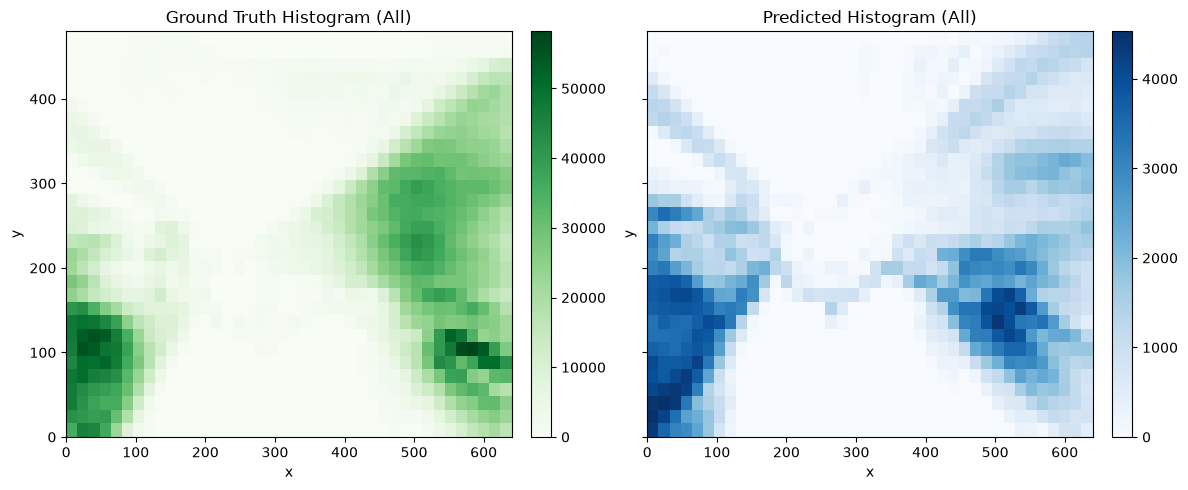

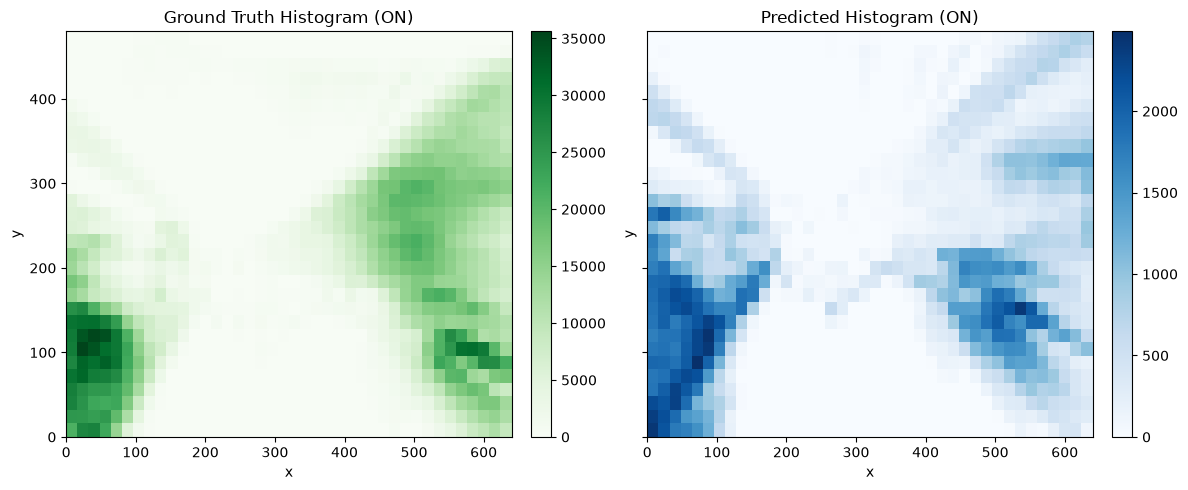

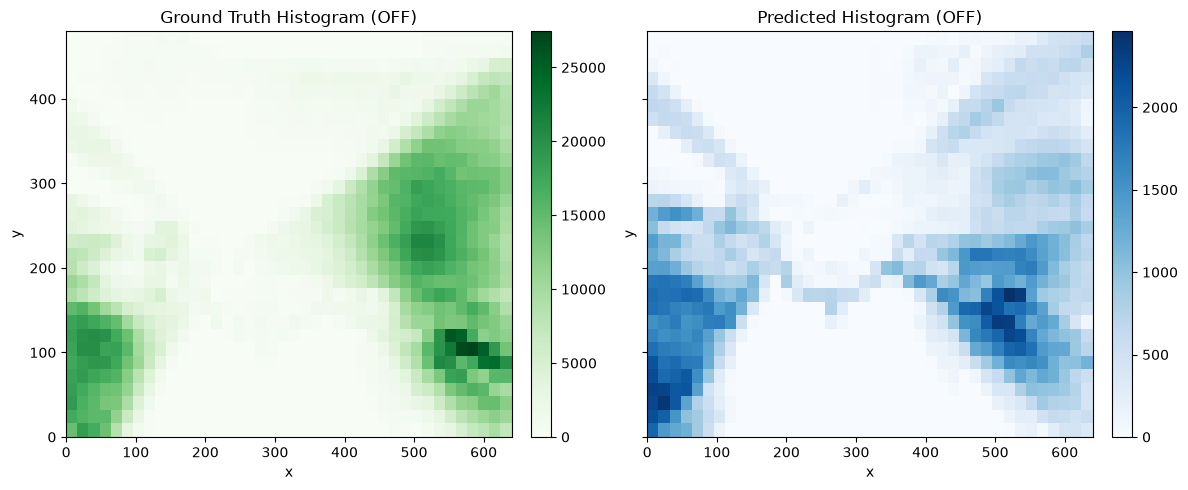

Metric                 | All          | ON           | OFF         
-----------------------------------------------------------------
GT events              | 12,061,433   | 6,530,366    | 5,531,067   
Synthetic events       | 1,058,140    | 518,951      | 539,189     
Event ratio (Comp.)    | 8.77%        | 7.95%        | 9.75%       
Occupied GT cells      | 1,047        | 1,008        | 1,044       
Occupied Pred cells    | 848          | 825          | 815         
TP cells               | 734          | 671          | 720         
FP cells               | 26           | 40           | 21          
FN cells               | 313          | 337          | 324         
Precision              | 96.6%        | 94.4%        | 97.2%       
Recall                 | 70.1%        | 66.6%        | 69.0%       
F1 Score               | 81.2%        | 78.1%        | 80.7%       
Mean Coverage          | 26.47        | 25.72        | 15.14       
Median Coverage        | 0.75         | 0.72      

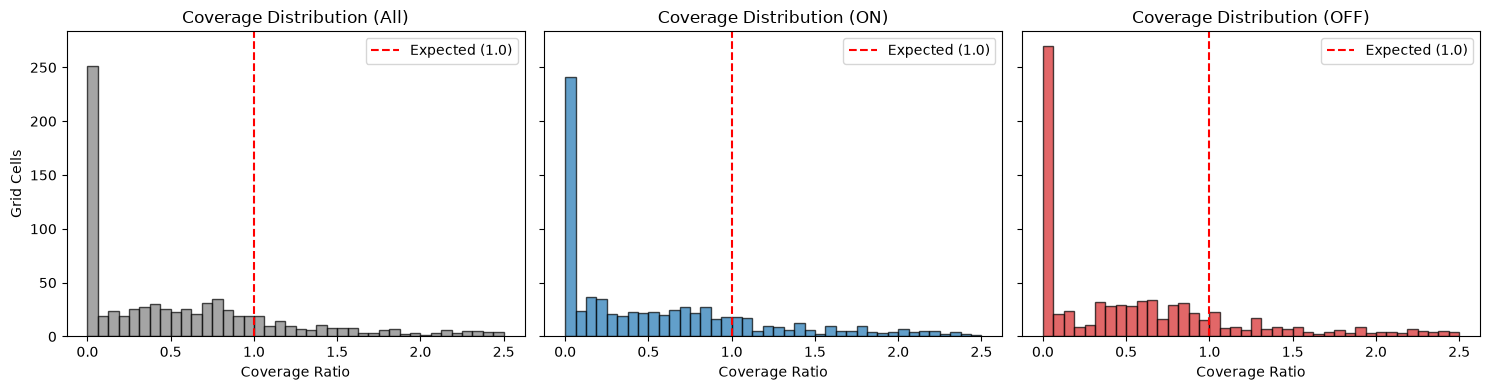

In [31]:
import h5py
import hdf5plugin
from framework.utils.dsec.eventslicer import EventSlicer

width, height = 640, 480
grid_size = 16
threshold = 0.25

with h5py.File(gt_path, "r") as gt_file, \
        h5py.File(pred_path, "r") as pred_file:
            
    gt_slicer = EventSlicer(gt_file)
    pred_slicer = EventSlicer(pred_file)

    # Manually set the time range for evaluation window in microseconds (us)

    start_us_gt = gt_slicer.get_start_time_us()
    start_us_pred = pred_slicer.get_start_time_us()

    end_us_gt = gt_slicer.get_final_time_us()
    end_us_pred = pred_slicer.get_final_time_us()



    start_us_gt = end_us_gt - 1_000_000
    start_us_pred = end_us_pred - 1_000_000

    window_us = 1_000_000
    cnt = 1

    current_gt = start_us_gt
    current_pred = start_us_pred

    while current_gt < end_us_gt and current_pred < end_us_pred:

        #current_gt_end = min(current_gt + window_us, end_us_gt)
        #current_pred_end = min(current_pred + window_us, end_us_pred)
        current_gt_end = end_us_gt
        current_pred_end = end_us_pred

        gt_raw_evs = gt_slicer.get_events(current_gt, current_gt_end)
        pred_raw_evs = pred_slicer.get_events(current_pred, current_pred_end)

        gt_on = filter_polarity(gt_raw_evs, 1)
        gt_off = filter_polarity(gt_raw_evs, 0)
        pred_on = filter_polarity(pred_raw_evs, 1)
        pred_off = filter_polarity(pred_raw_evs, 0)

        metrics_all, cov_all = compute_metrics("(All)", gt_raw_evs, pred_raw_evs, width, height, grid_size, threshold)
        metrics_on, cov_on = compute_metrics("(ON)", gt_on, pred_on, width, height, grid_size, threshold)
        metrics_off, cov_off = compute_metrics("(OFF)", gt_off, pred_off, width, height, grid_size, threshold)

        print_metrics_table(metrics_all, metrics_on, metrics_off)
        plot_coverage_histograms(cov_all, cov_on, cov_off)
        
        cnt += 1
        if cnt >= 2:
            break